# Gestion de projet SIG

La classe `Project` structure un projet cartographique sur le disque :
un dossier `data/` pour les sources, un dossier `output/` pour les rendus,
un CRS de référence, un inventaire des jeux de données et un manifeste
`project.json` qui fige l'état du projet.

Workflow type : **init → add_data → organize → load_data → save_output → save_manifest / validate**.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")  # voir les messages de Project

import cartograpy as cp
from cartograpy.data import Bound
from cartograpy.project import Project

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## 1. Créer et initialiser le projet

`init()` crée les dossiers `data/` et `output/`. Le `crs` est le système de
coordonnées de travail — ici l'UTM zone 30N, adapté à la Côte d'Ivoire.

In [2]:
projet = Project(path="mon_projet_sig", crs="EPSG:32630")
projet.init()
projet.infos()

✅ Projet initialisé dans : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig


   📁 C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\data


   📁 C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\output


📋 Projet : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig


   🌐 CRS : EPSG:32630


   📁 data/   : ✅ (0 fichier(s))


   📁 output/ : ✅ (0 fichier(s))


{'path': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig',
 'crs': 'EPSG:32630',
 'data_dir': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\data',
 'output_dir': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\output',
 'data_exists': True,
 'output_exists': True,
 'vector_files': 0,
 'raster_files': 0,
 'tabular_files': 0,
 'other_files': 0,
 'total_data_files': 0,
 'output_files': 0}

## 2. Ajouter des données

`add_data` accepte un objet en mémoire (GeoDataFrame, DataFrame, raster) ou
un chemin de fichier existant — dans ce cas le fichier est copié dans
`data/` avec ses sidecars (`.shx`, `.dbf`, `.prj`...).

In [3]:
bound = Bound()
regions = bound.get_admin("CIV", adm=1)  # régions, via GeoBoundaries

projet.add_data(
    regions,
    file_extension="gpkg",
    filename="regions_civ",
    category="vector",
    overwrite=True,
)

C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Created 14 records


✅ Fichier sauvegardé : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\data\vector\regions_civ.gpkg


✅ Données ajoutées : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\data\vector\regions_civ.gpkg


'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\data\\vector\\regions_civ.gpkg'

In [4]:
# Un fichier déjà sur le disque : copié dans data/ avec ses sidecars
# projet.add_data("../data/vector/rivieres.shp", category="vector", overwrite=True)

projet.list_datasets()

[{'name': 'regions_civ',
  'type': 'vector',
  'main_file': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\data\\vector\\regions_civ.gpkg',
  'extension': '.gpkg',
  'sidecars': [],
  'total_size': 286720,
  'path': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\data\\vector'}]

## 3. Organiser le dossier data/

`organize_project()` déplace chaque fichier de `data/` vers `vector/`,
`raster/` ou `tabular/` selon son extension.

In [5]:
projet.organize_project()
projet.infos()

📂 Organisation terminée dans : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\data


   vector/  → 1 fichier(s)


   raster/  → 0 fichier(s)


   tabular/ → 0 fichier(s)


📋 Projet : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig


...

      ├── raster    : 0


      ├── tabulaire : 0


      └── autre     : 0


   📁 output/ : ✅ (0 fichier(s))


{'path': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig',
 'crs': 'EPSG:32630',
 'data_dir': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\data',
 'output_dir': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig\\output',
 'data_exists': True,
 'output_exists': True,
 'vector_files': 1,
 'raster_files': 0,
 'tabular_files': 0,
 'other_files': 0,
 'total_data_files': 1,
 'output_files': 0}

## 4. Recharger une couche et la cartographier

`load_data` retrouve un jeu de données par son nom (avec ou sans extension)
et renvoie un GeoDataFrame / DataFrame / raster prêt à l'emploi.

⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326


🧭 Flèche du Nord ajoutée (map-utils)


C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:977: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  return self._add_gdf_layer(


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


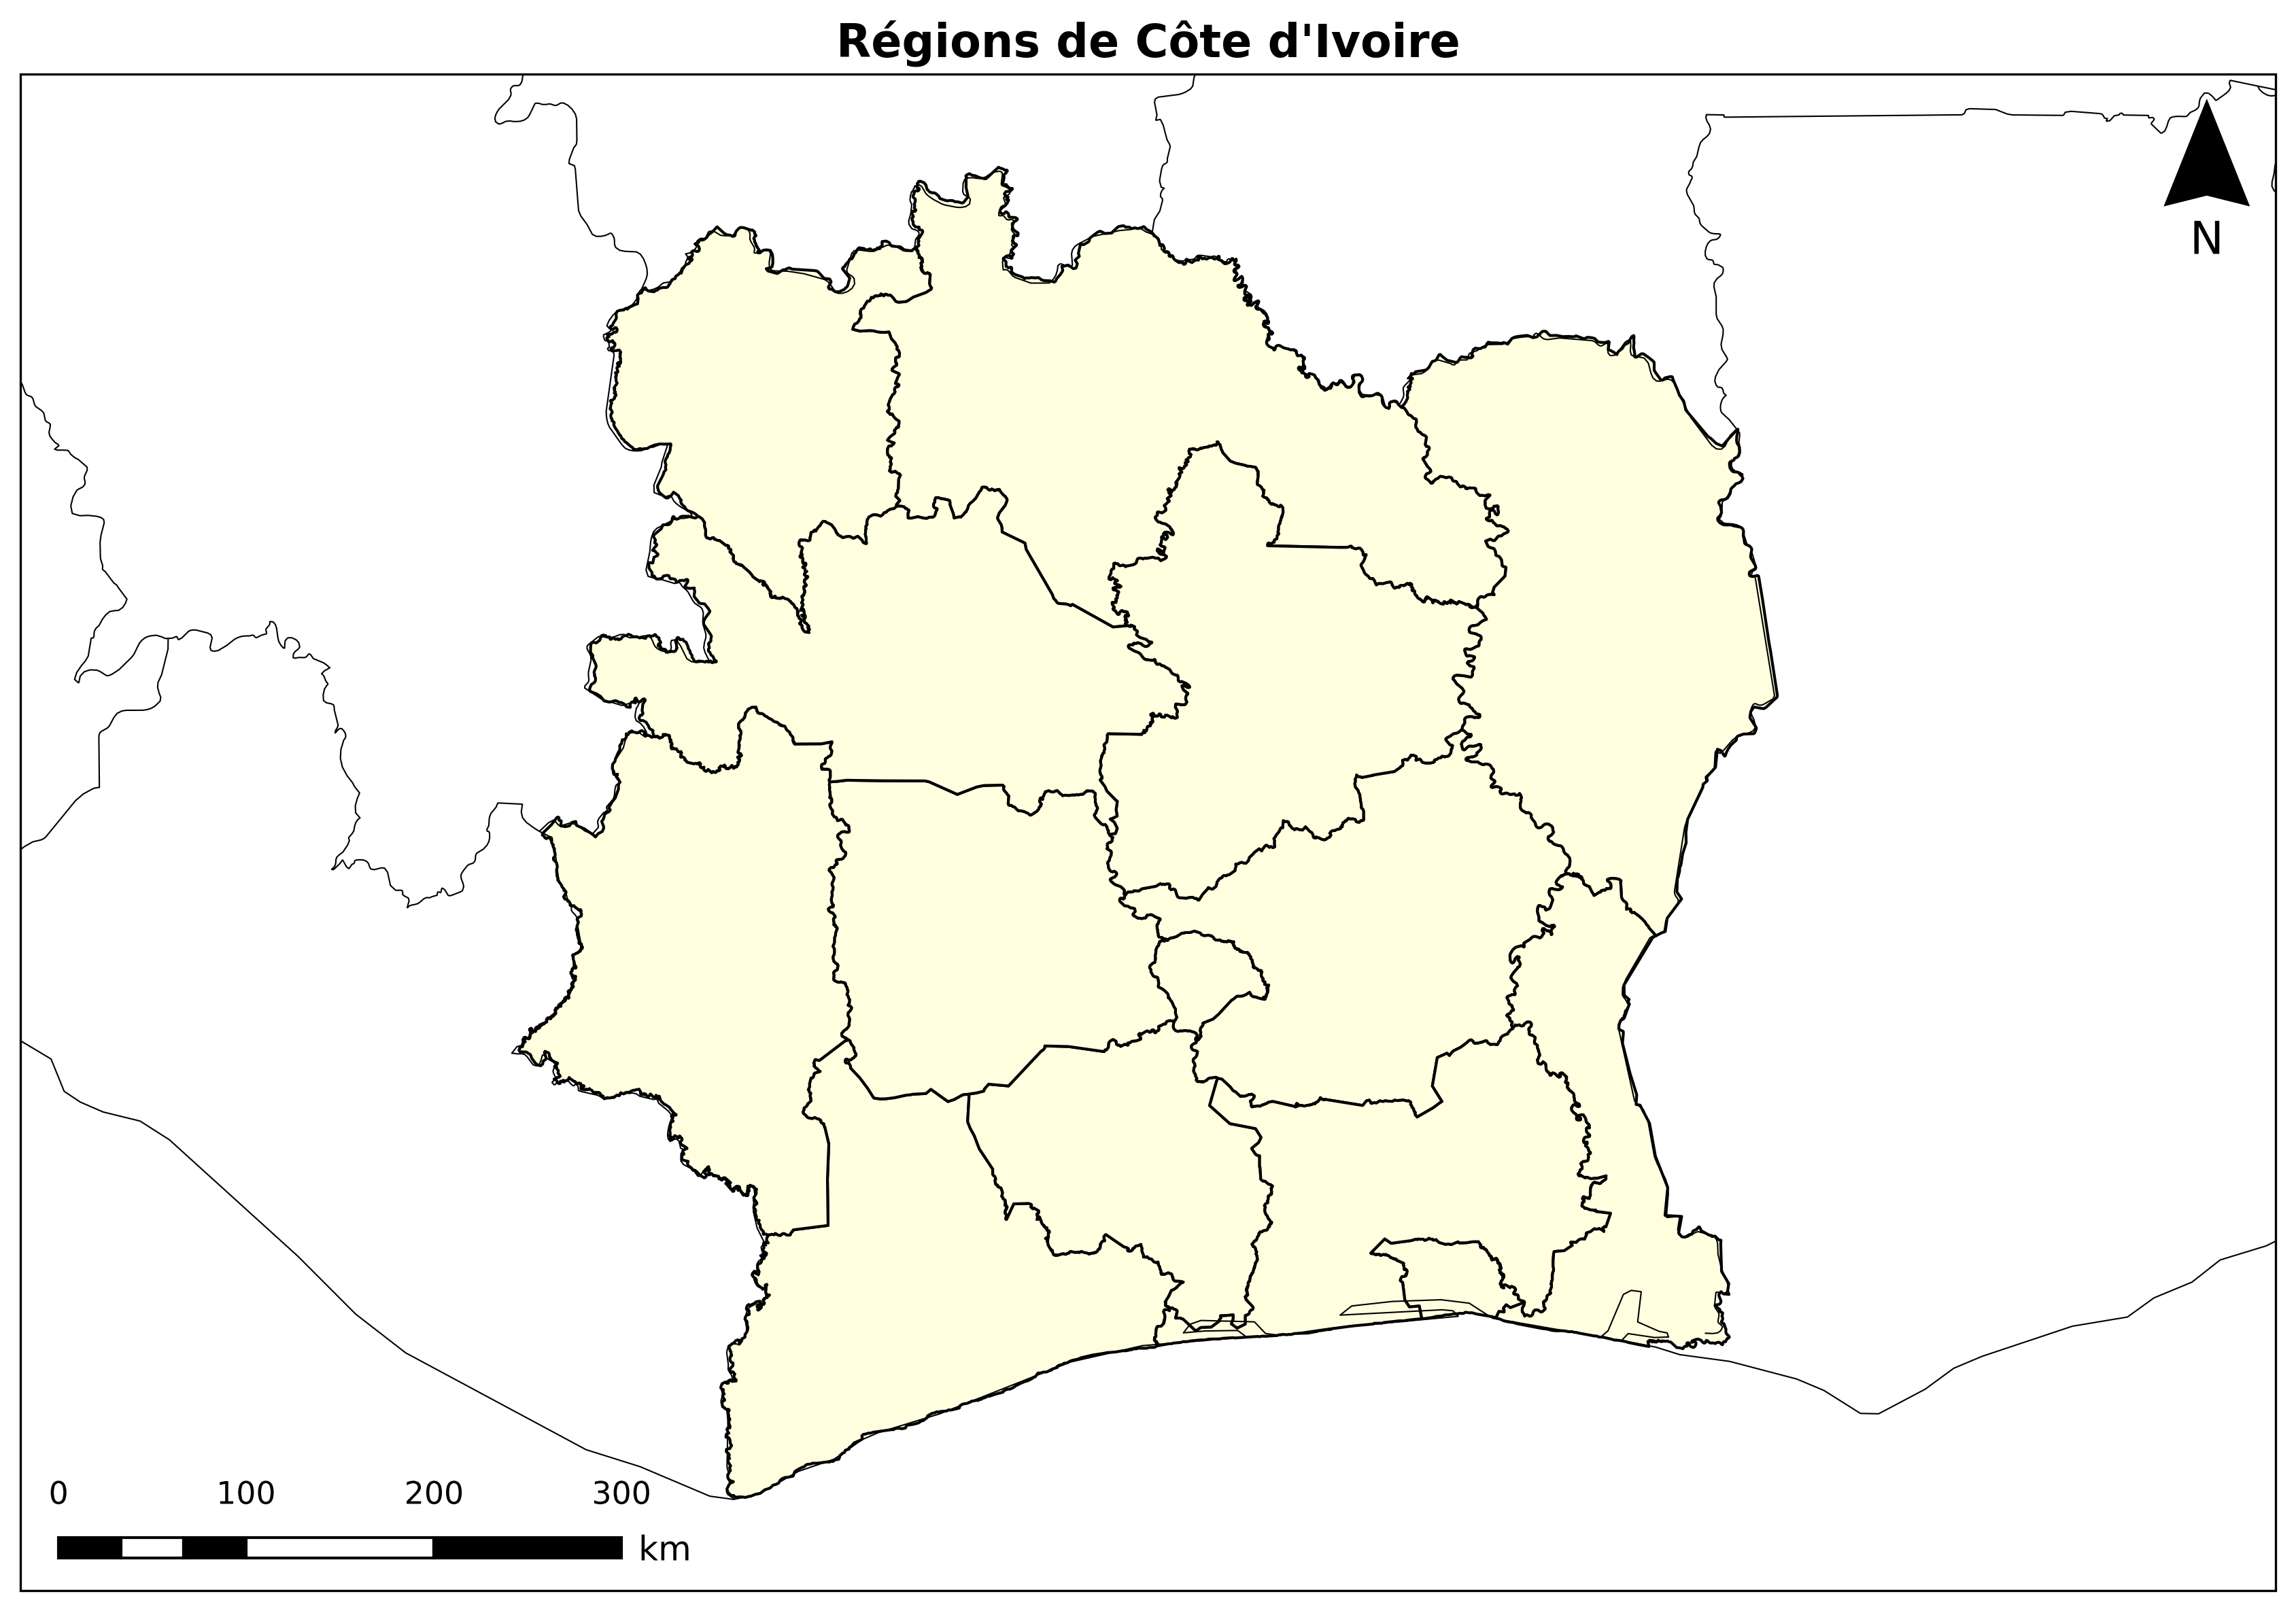

In [6]:
gdf = projet.load_data("regions_civ")

m = cp.Map(title="Régions de Côte d'Ivoire")
m.add_polygons(gdf, facecolor="lightyellow", edge_color="black", alpha=1)
m.add_north_arrow()
m.add_scale_bar()
m.show()

## 5. Écrire un résultat dans output/

`save_output` est le pendant de `add_data` mais cible `output/`.

In [7]:
chefs_lieux = gdf.copy()
chefs_lieux["geometry"] = gdf.geometry.centroid

projet.save_output(chefs_lieux, "geojson", filename="chefs_lieux", overwrite=True)

carte = projet.output_dir + "/regions_civ.png"
m.save(carte, dpi=200)

C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
Created 14 records


✅ Fichier sauvegardé : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\output\chefs_lieux.geojson


✅ Sortie sauvegardée : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\output\chefs_lieux.geojson


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


...

   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


Carte sauvegardée: C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\output/regions_civ.png


## 6. Figer et vérifier le projet

`save_manifest()` écrit `project.json` (CRS, inventaire, date).
`validate(deep=True)` contrôle l'intégrité : sidecars manquants ou
orphelins, noms ambigus, fichiers illisibles.

In [8]:
projet.save_manifest()
projet.validate(deep=True)

📄 Manifeste sauvegardé : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet_sig\project.json


🔍 Validation du projet : ✅ valide


   Aucun problème détecté.


{'valid': True,
 'data_dir_exists': True,
 'output_dir_exists': True,
 'warnings': [],
 'errors': []}

In [9]:
# Nettoyer les rendus quand on veut repartir de zéro
# projet.clean_output()

projet.load_manifest()

{'project_path': 'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet_sig',
 'crs': 'EPSG:32630',
 'data_dir': 'data',
 'output_dir': 'output',
 'created_at': '2026-08-30T12:37:35.974974+00:00',
 'datasets': [{'name': 'regions_civ',
   'type': 'vector',
   'extension': '.gpkg',
   'main_file': 'data\\vector\\regions_civ.gpkg',
   'sidecars': [],
   'total_size': 286720}]}